# Ir Além 2 - Machine Learning no Agronegócio (Capítulo 1)

Este notebook é um ensaio preparatório para a atividade do Capítulo 10. Usamos a base `produtos_agricolas.csv`, que reúne informações de solo e clima para diferentes culturas agrícolas.

A ideia foi fazer uma primeira exploração dos dados, testar abordagens e escolhas diferentes — como outras culturas para análise de perfil e algoritmos distintos para modelagem — para que o trabalho do Capítulo 10 pudesse ser refinado a partir desse experimento.

A linguagem segue um tom direto, explicando o raciocínio por trás de cada etapa sem aprofundar demais em detalhes técnicos.

## 0. Instalação das dependências

Primeiro vamos instalar os pacotes necessários. A célula abaixo cuida disso.

In [1]:
!pip install pandas seaborn matplotlib scikit-learn

## 1. Carregando as bibliotecas e os dados

Carregamos as bibliotecas que vamos utilizar no notebook e lemos o arquivo CSV. Damos uma olhada nas primeiras linhas para confirmar que a base veio correta.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

sns.set_theme(style="whitegrid")

df = pd.read_csv('../produtos_agricolas.csv')
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 2. Dicionário de tradução das culturas

Os nomes das culturas estão em inglês na base original. Para facilitar a leitura dos gráficos e deixar o notebook mais apresentável, criamos uma tradução para o português.

In [3]:
traducao_culturas = {
    'rice': 'Arroz',
    'maize': 'Milho',
    'chickpea': 'Grão-de-bico',
    'kidneybeans': 'Feijão-vermelho',
    'pigeonpeas': 'Feijão-guandu',
    'mothbeans': 'Feijão-moth',
    'mungbean': 'Feijão-mungo',
    'blackgram': 'Feijão-preto',
    'lentil': 'Lentilha',
    'pomegranate': 'Romã',
    'banana': 'Banana',
    'mango': 'Manga',
    'grapes': 'Uva',
    'watermelon': 'Melancia',
    'muskmelon': 'Melão',
    'apple': 'Maçã',
    'orange': 'Laranja',
    'papaya': 'Mamão',
    'coconut': 'Coco',
    'cotton': 'Algodão',
    'jute': 'Juta',
    'coffee': 'Café'
}

df['cultura'] = df['label'].map(traducao_culturas)

df[['label', 'cultura']].drop_duplicates().sort_values('cultura').reset_index(drop=True)

,label,cultura
0,cotton,Algodão
1,rice,Arroz
2,banana,Banana
3,coffee,Café
4,coconut,Coco
5,pigeonpeas,Feijão-guandu
6,mothbeans,Feijão-moth
7,mungbean,Feijão-mungo
8,blackgram,Feijão-preto
9,kidneybeans,Feijão-vermelho


## 3. Análise exploratória inicial

Conferimos o formato da base, os tipos de cada coluna, se existe algum valor nulo e as estatísticas descritivas. Esse passo é importante para garantir que os dados estão prontos para as próximas etapas.

In [4]:
print('Dimensões da base:', df.shape)
print('\nInformações dos dados:')
df.info()

print('\nValores ausentes por coluna:')
print(df.isnull().sum())

df.describe()

Dimensões da base: (2200, 9)

Informações dos dados:
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
 8   cultura      2200 non-null   str    
dtypes: float64(4), int64(3), str(2)
memory usage: 154.8 KB

Valores ausentes por coluna:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
cultura        0
dtype: int64


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


### Comentários iniciais

O conjunto de dados tem 2200 registros e 8 colunas, sendo 7 variáveis numéricas (nitrogênio, fósforo, potássio, temperatura, umidade, pH e precipitação) e uma variável alvo com a cultura. Não identificamos valores ausentes, o que simplificou o processo.

As escalas das variáveis são bem distintas: o pH fica entre 3,5 e 9,9, enquanto a chuva chega a quase 300 mm. Por isso, mais adiante aplicamos padronização antes de treinar os modelos.

## 4. Análise descritiva com gráficos

Criamos seis gráficos para visualizar os dados de forma mais clara. A ideia foi observar padrões, distribuições e diferenças entre as culturas antes de partir para a modelagem.

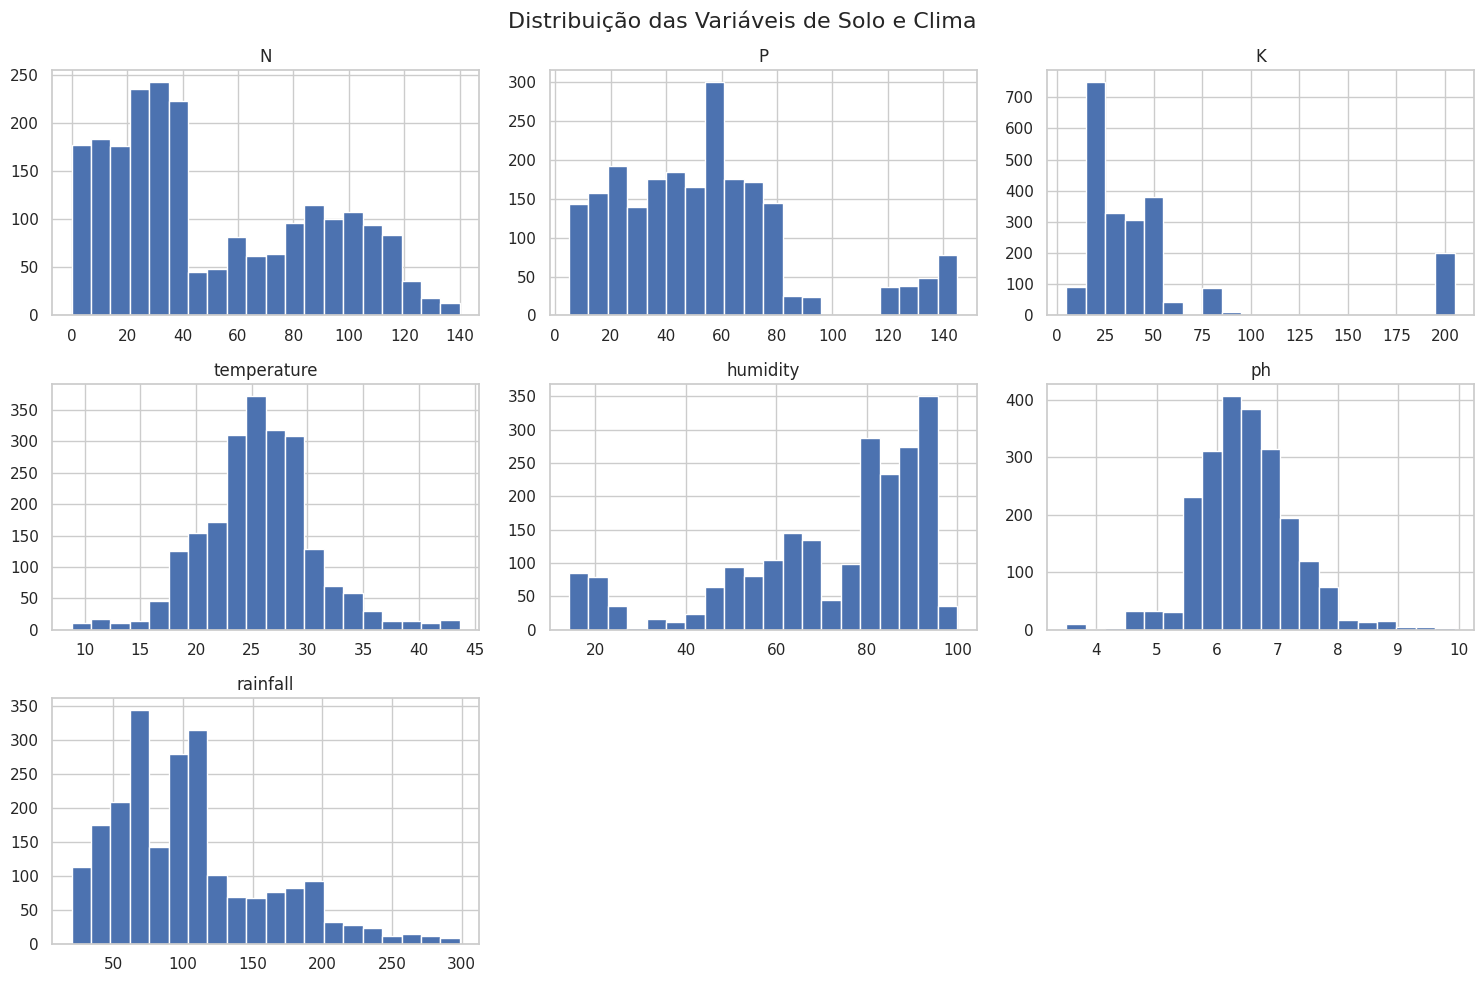

In [5]:
# Gráfico 1: Distribuição das variáveis numéricas
variaveis_numericas = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

df[variaveis_numericas].hist(bins=20, figsize=(15, 10))
plt.suptitle('Distribuição das Variáveis de Solo e Clima', fontsize=16)
plt.tight_layout()
plt.show()

### Análise do Gráfico 1

As distribuições mostram que cada variável se comporta de um jeito. Enquanto algumas têm valores mais concentrados, outras se distribuem de forma mais ampla.

Isso reforça a importância de padronizar os dados antes de aplicar os modelos. Do contrário, variáveis com escalas maiores poderiam acabar tendo mais peso na decisão do algoritmo.

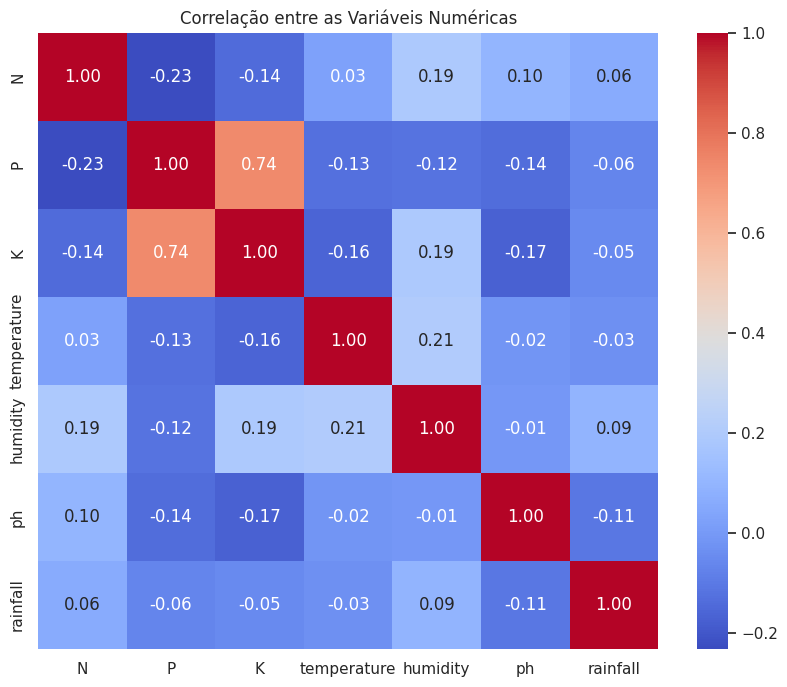

In [6]:
# Gráfico 2: Matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(df[variaveis_numericas].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlação entre as Variáveis Numéricas')
plt.show()

### Análise do Gráfico 2

A matriz de correlação não aponta relações lineares muito fortes entre a maioria das variáveis. Isso sugere que cada uma delas pode contribuir com informações distintas para a classificação.

Correlações baixas não querem dizer que a variável seja irrelevante. Muitas vezes, a cultura é definida pela combinação dos fatores e não por uma relação linear simples.

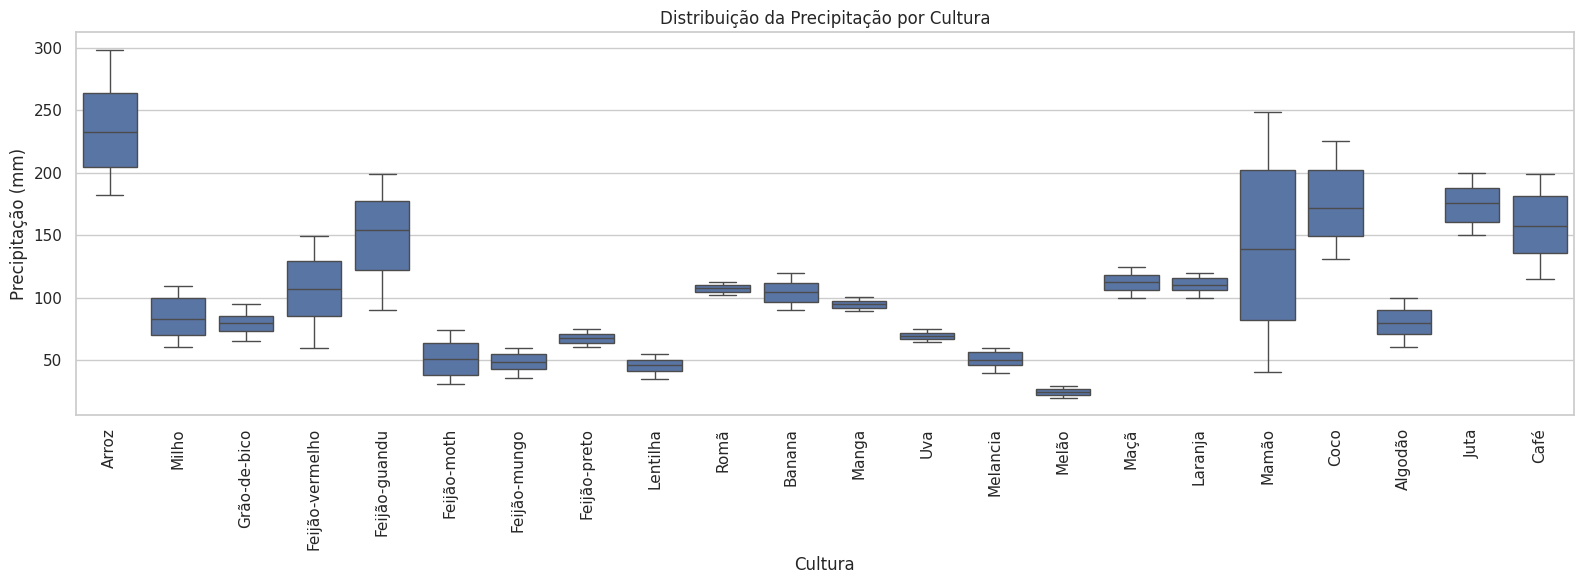

In [7]:
# Gráfico 3: Precipitação por cultura
plt.figure(figsize=(16, 6))
sns.boxplot(x='cultura', y='rainfall', data=df)
plt.xticks(rotation=90)
plt.title('Distribuição da Precipitação por Cultura')
plt.xlabel('Cultura')
plt.ylabel('Precipitação (mm)')
plt.tight_layout()
plt.show()

### Análise do Gráfico 3

O boxplot de precipitação é um dos gráficos mais informativos. Dá para ver claramente que cada cultura tem uma faixa de chuva diferente.

Culturas como arroz aparecem com níveis altos de precipitação, enquanto outras, como uva e grão-de-bico, ficam em faixas bem mais baixas. Isso mostra que a chuva é um fator relevante para separar os tipos de plantio.

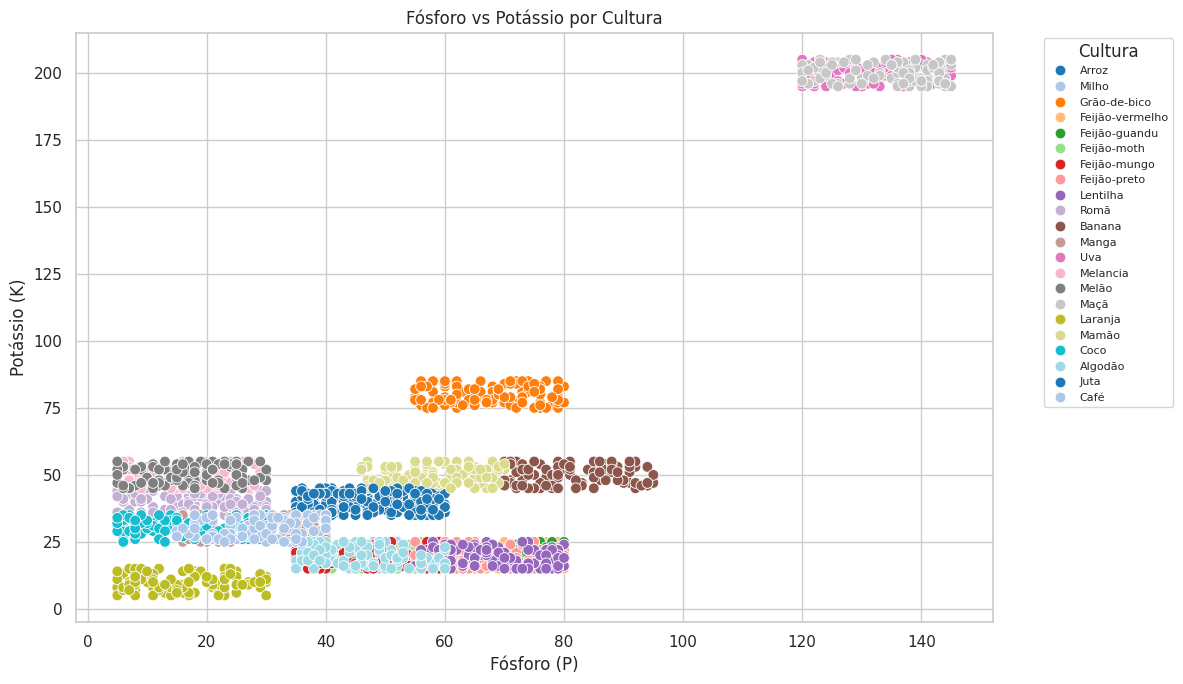

In [8]:
# Gráfico 4: Relação entre Fósforo e Potássio com cores por cultura
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df,
    x='P',
    y='K',
    hue='cultura',
    palette='tab20',
    s=60
)
plt.title('Fósforo vs Potássio por Cultura')
plt.xlabel('Fósforo (P)')
plt.ylabel('Potássio (K)')
plt.legend(title='Cultura', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=1)
plt.tight_layout()
plt.show()

### Análise do Gráfico 4

O gráfico de dispersão entre fósforo e potássio revela agrupamentos interessantes. Algumas culturas ocupam regiões bem definidas, o que indica que a combinação desses nutrientes ajuda a distinguir os tipos de plantio.

Isso também explica por que os modelos de Machine Learning conseguem um bom desempenho: existem padrões nos dados que facilitam a separação entre as classes.

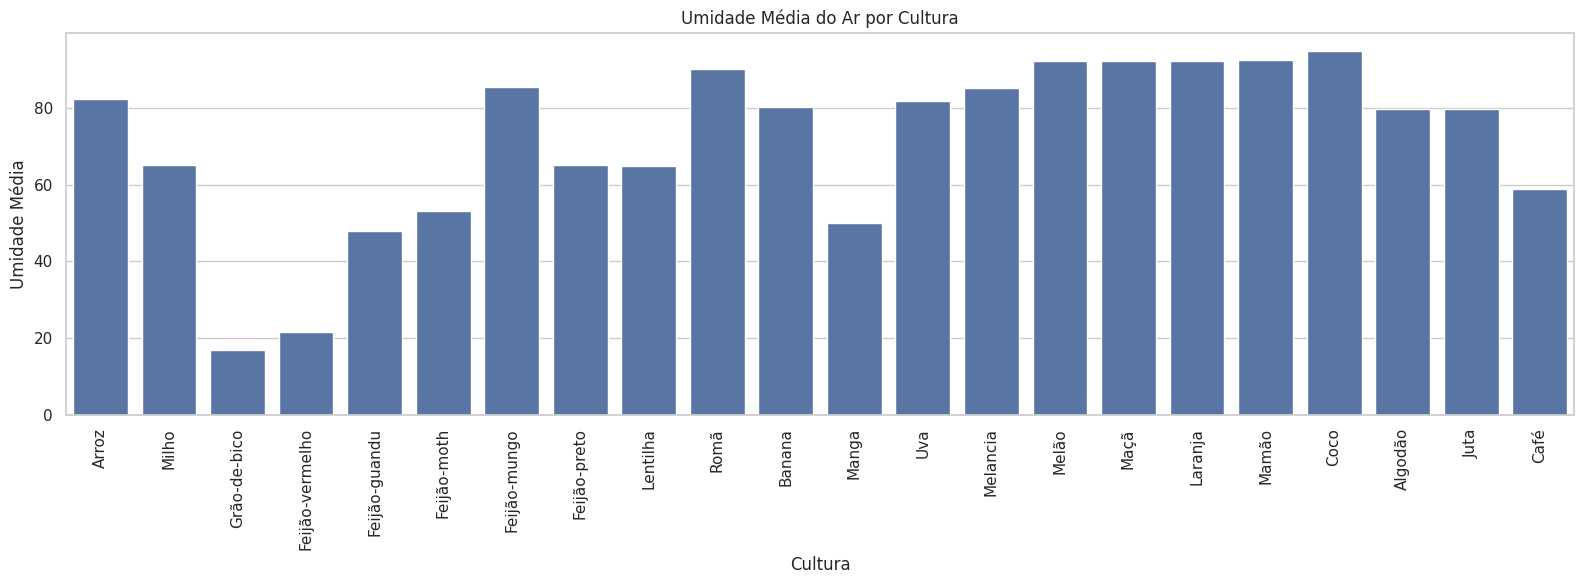

In [9]:
# Gráfico 5: Umidade média por cultura
plt.figure(figsize=(16, 6))
sns.barplot(x='cultura', y='humidity', data=df, estimator='mean', errorbar=None)
plt.xticks(rotation=90)
plt.title('Umidade Média do Ar por Cultura')
plt.xlabel('Cultura')
plt.ylabel('Umidade Média')
plt.tight_layout()
plt.show()

### Análise do Gráfico 5

O gráfico de umidade média mostra que algumas culturas preferem ambientes mais úmidos, enquanto outras se desenvolvem melhor em condições mais secas.

Essa análise fica mais completa quando combinada com os dados de chuva e temperatura. Uma cultura não depende de uma única variável, então o ideal é observar o conjunto de condições.

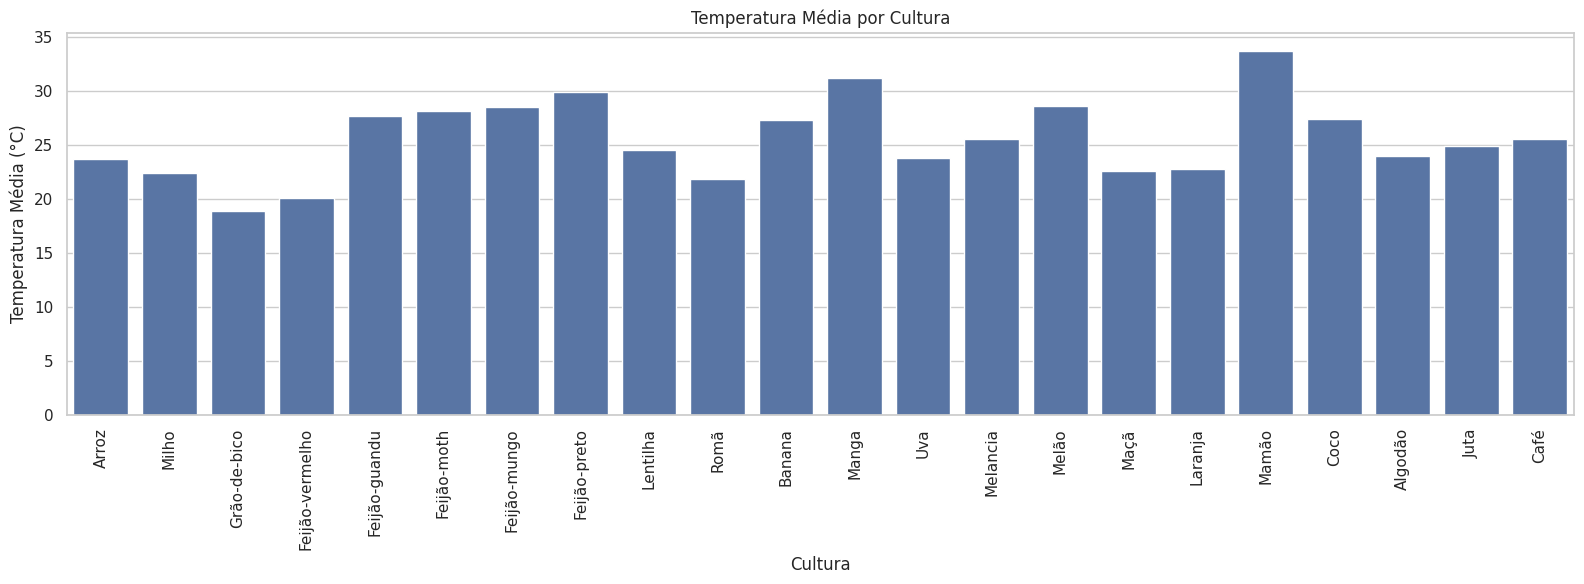

In [10]:
# Gráfico 6: Temperatura média por cultura
plt.figure(figsize=(16, 6))
sns.barplot(x='cultura', y='temperature', data=df, estimator='mean', errorbar=None)
plt.xticks(rotation=90)
plt.title('Temperatura Média por Cultura')
plt.xlabel('Cultura')
plt.ylabel('Temperatura Média (°C)')
plt.tight_layout()
plt.show()

### Análise do Gráfico 6

A temperatura média também varia entre as culturas. Algumas aparecem associadas a climas mais quentes, enquanto outras toleram temperaturas mais amenas.

Junto com os gráficos anteriores, isso ajuda a montar um panorama mais completo do perfil agrícola de cada cultura.

## 5. Perfil ideal de solo e clima

Para traçar o perfil ideal, calculamos a média de cada variável para cada cultura. Isso não significa que exista apenas um valor correto, mas ajuda a entender o comportamento típico de cada plantação dentro da base.

Escolhemos analisar **Milho**, **Algodão** e **Banana**. Três culturas com perfis distintos entre si, para variar em relação às que seriam analisadas no Capítulo 10.

In [11]:
# Média geral da base
media_geral = df[variaveis_numericas].mean()

# Perfil médio por cultura
perfis = df.groupby('cultura')[variaveis_numericas].mean().round(2)

# Culturas escolhidas para esta análise
culturas_escolhidas = ['Milho', 'Algodão', 'Banana']
comparativo = perfis.loc[culturas_escolhidas]

print('Média geral dos dados:')
display(media_geral.round(2).to_frame('Média Geral'))

print('\nPerfil médio das culturas selecionadas:')
display(comparativo)

Média geral dos dados:


,Média Geral
N,50.55
P,53.36
K,48.15
temperature,25.62
humidity,71.48
ph,6.47
rainfall,103.46



Perfil médio das culturas selecionadas:


,N,P,K,temperature,humidity,ph,rainfall
cultura,,,,,,,
Milho,77.76,48.44,19.79,22.39,65.09,6.25,84.77
Algodão,117.77,46.24,19.56,23.99,79.84,6.91,80.40
Banana,100.23,82.01,50.05,27.38,80.36,5.98,104.63


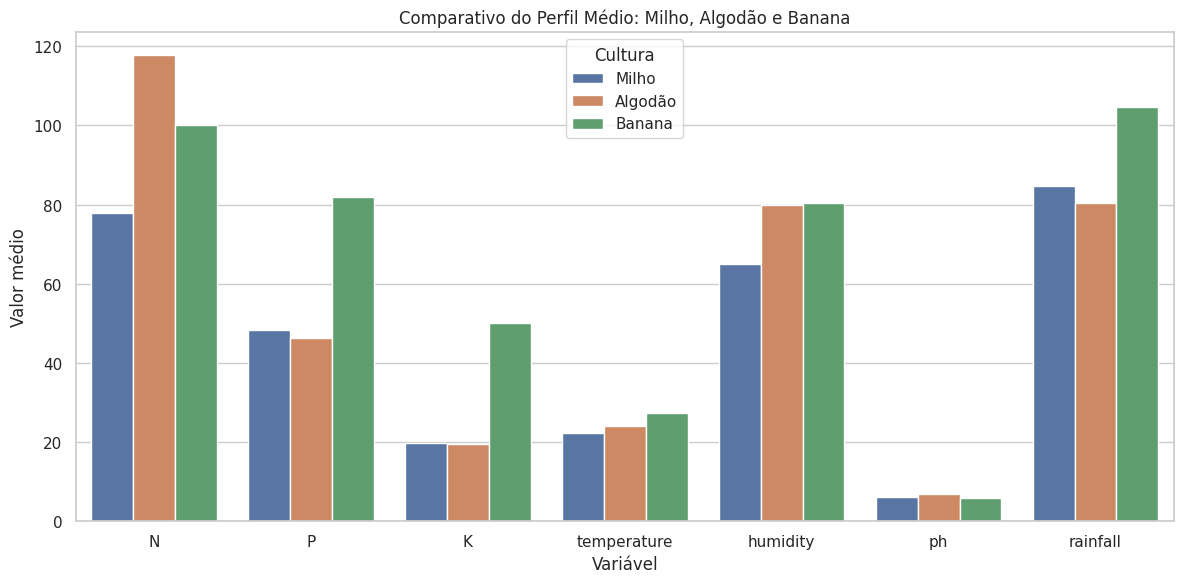

In [12]:
# Gráfico comparativo das três culturas
comparativo_plot = comparativo.reset_index().melt(id_vars='cultura', var_name='Variável', value_name='Média')

plt.figure(figsize=(12, 6))
sns.barplot(data=comparativo_plot, x='Variável', y='Média', hue='cultura')
plt.title('Comparativo do Perfil Médio: Milho, Algodão e Banana')
plt.xlabel('Variável')
plt.ylabel('Valor médio')
plt.legend(title='Cultura')
plt.tight_layout()
plt.show()

### Análise do perfil ideal

Os valores médios revelam diferenças claras entre as três culturas.

O **Milho** se caracteriza por um teor de nitrogênio acima da média da base, mas potássio baixo (cerca de 20), temperatura mais amena e precipitação abaixo da média geral. O perfil sugere uma cultura que responde bem a solos com bom nitrogênio, mas sem exigir tanto potássio ou chuva.

O **Algodão** apresenta o maior nível de nitrogênio entre todas as 22 culturas da base (117,77), o que faz sentido para uma cultura que demanda bastante adubação nitrogenada. O potássio, por outro lado, é baixo, assim como a precipitação. A umidade do ar fica acima da média, indicando preferência por ambientes mais úmidos.

A **Banana** se destaca pelos valores elevados de fósforo (82,01) e nitrogênio (100,23), além de temperatura mais alta (27,38 °C). A precipitação fica próxima da média geral, então não é uma cultura tão dependente de chuva intensa quanto o arroz, por exemplo. O pH levemente ácido (5,98) também aparece como uma característica relevante.

## 6. Desenvolvimento dos modelos preditivos

Nesta etapa treinamos cinco modelos de classificação com algoritmos diferentes. O objetivo continua sendo prever qual cultura é mais adequada com base nas condições de solo e clima.

Os modelos escolhidos foram:

- Gradient Boosting;
- Extra Trees;
- Naive Bayes (Gaussian);
- MLP (Rede Neural Artificial);
- LDA (Análise Discriminante Linear).

Mantivemos o `StandardScaler` para padronizar as variáveis e o `random_state=42` nos modelos que oferecem esse parâmetro.

In [13]:
# Preparação dos dados
X = df.drop(['label', 'cultura'], axis=1)
y = df['cultura']

# Divisão treino/teste com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Padronização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Definição dos 5 novos algoritmos
modelos = {
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Extra Trees': ExtraTreesClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'MLP (Rede Neural)': MLPClassifier(random_state=42, max_iter=1000),
    'LDA': LinearDiscriminantAnalysis()
}

# Treinamento e avaliação
resultados = []
predicoes_modelos = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    predicoes = modelo.predict(X_test_scaled)
    predicoes_modelos[nome] = predicoes

    resultados.append({
        'Modelo': nome,
        'Acurácia': accuracy_score(y_test, predicoes),
        'Precisão': precision_score(y_test, predicoes, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, predicoes, average='weighted', zero_division=0),
        'F1-score': f1_score(y_test, predicoes, average='weighted', zero_division=0)
    })

df_resultados = pd.DataFrame(resultados).sort_values(by='Acurácia', ascending=False)
df_resultados

,Modelo,Acurácia,Precisão,Recall,F1-score
2,Naive Bayes,1.000000,1.000000,1.000000,1.000000
1,Extra Trees,0.995455,0.995671,0.995455,0.995452
0,Gradient Boosting,0.990909,0.991234,0.990909,0.990905
3,MLP (Rede Neural),0.988636,0.989266,0.988636,0.988683
4,LDA,0.977273,0.978945,0.977273,0.977456


### Análise dos modelos

A tabela acima organiza os resultados por acurácia, mostrando também precisão, recall e F1-score. Como o problema envolve 22 classes, essas métricas combinadas ajudam a avaliar o desempenho além do percentual bruto de acertos.

O **Naive Bayes** surpreendeu com acurácia perfeita (1,00), superando até modelos mais complexos. Isso sugere que as variáveis seguem uma distribuição que favorece a abordagem probabilística do algoritmo.

O **Extra Trees** (0,995) e o **Gradient Boosting** (0,991) também tiveram desempenho excelente, errando apenas 2 e 4 amostras respectivamente. Já o **MLP** (0,989) ficou próximo, mas exigiu mais iterações para convergir.

O **LDA** apresentou o menor desempenho (0,977), com 10 erros concentrados principalmente em culturas de perfil semelhante, como leguminosas (feijão-guandu, feijão-vermelho, lentilha) e entre arroz e juta. Isso indica que a separação linear assumida pelo LDA não captura bem certas fronteiras entre classes próximas.

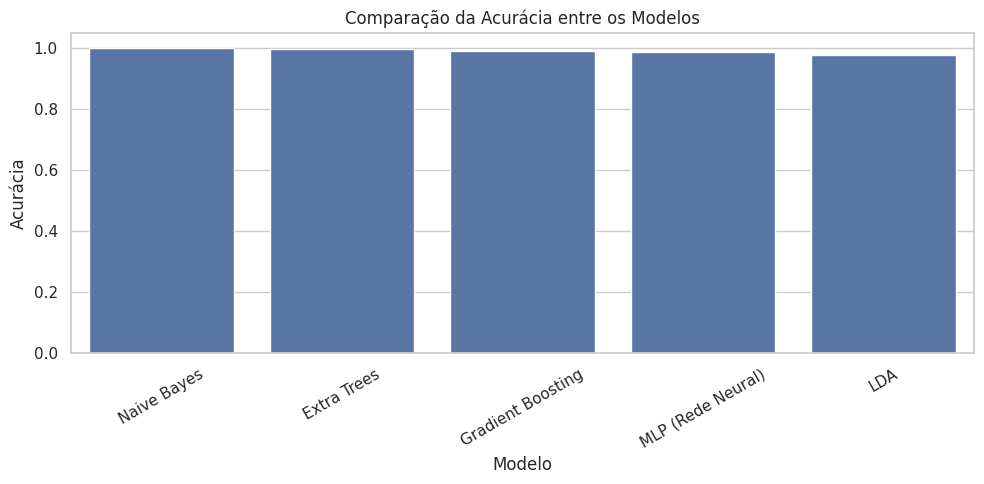

In [14]:
# Gráfico comparativo de acurácia
plt.figure(figsize=(10, 5))
sns.barplot(data=df_resultados, x='Modelo', y='Acurácia')
plt.title('Comparação da Acurácia entre os Modelos')
plt.ylim(0, 1.05)
plt.xticks(rotation=30)
plt.ylabel('Acurácia')
plt.tight_layout()
plt.show()

In [15]:
# Relatório do melhor modelo
melhor_modelo_nome = df_resultados.iloc[0]['Modelo']
melhor_predicao = predicoes_modelos[melhor_modelo_nome]

print('Melhor modelo:', melhor_modelo_nome)
print('\nRelatório de classificação:')
print(classification_report(y_test, melhor_predicao, zero_division=0))

Melhor modelo: Naive Bayes

Relatório de classificação:
                 precision    recall  f1-score   support

        Algodão       1.00      1.00      1.00        20
          Arroz       1.00      1.00      1.00        20
         Banana       1.00      1.00      1.00        20
           Café       1.00      1.00      1.00        20
           Coco       1.00      1.00      1.00        20
  Feijão-guandu       1.00      1.00      1.00        20
    Feijão-moth       1.00      1.00      1.00        20
   Feijão-mungo       1.00      1.00      1.00        20
   Feijão-preto       1.00      1.00      1.00        20
Feijão-vermelho       1.00      1.00      1.00        20
   Grão-de-bico       1.00      1.00      1.00        20
           Juta       1.00      1.00      1.00        20
        Laranja       1.00      1.00      1.00        20
       Lentilha       1.00      1.00      1.00        20
          Mamão       1.00      1.00      1.00        20
          Manga       1.00     

### Nota sobre a matriz de confusão

Optamos por não incluir a matriz de confusão neste ensaio. Com 22 culturas diferentes, o gráfico fica visualmente poluído e acaba não agregando tanto quanto a tabela de métricas e o gráfico de acurácia.

Para este momento de exploração inicial, a comparação por meio das métricas objetivas já atende bem ao propósito.

## 7. Conclusão

Este ensaio permitiu explorar a base de forma prática antes de partir para a versão final do Capítulo 10. A análise exploratória mostrou que as culturas agrícolas têm perfis distintos de solo e clima, com variáveis como precipitação, umidade, fósforo e potássio se destacando na separação entre os tipos de plantio.

No perfil ideal, observamos que o milho apresenta maior exigência de nitrogênio com temperatura mais amena, o algodão se destaca pelo maior teor de nitrogênio da base, e a banana combina altos níveis de fósforo e nitrogênio com temperaturas mais elevadas. Essas diferenças reforçam a importância de considerar múltiplos fatores ao recomendar uma cultura.

Na parte de Machine Learning, os cinco modelos testados apresentaram desempenhos variados. A tabela de métricas possibilita comparar os resultados de forma objetiva e serviu de base para escolher as abordagens que foram refinadas na entrega do Capítulo 10. A matriz de confusão foi deixada de lado por questões de visualização, já que a base possui muitas classes.

Como limitação, vale destacar que os dados são relativamente limpos e balanceados, o que nem sempre ocorre em cenários reais. Para a versão final, seria interessante testar tuning de hiperparâmetros, validar com dados de campo reais e incluir variáveis adicionais como tipo de solo e histórico de produtividade.